In [1]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

notebooks_folder = Path.cwd()
processed_folder = notebooks_folder.parent / "data" / "processed"


fund_master = pd.read_csv(processed_folder / "fund_master_cleaned.csv")
nav = pd.read_csv(processed_folder / "nav_history_cleaned.csv")
performance = pd.read_csv(processed_folder / "scheme_performance_cleaned.csv")

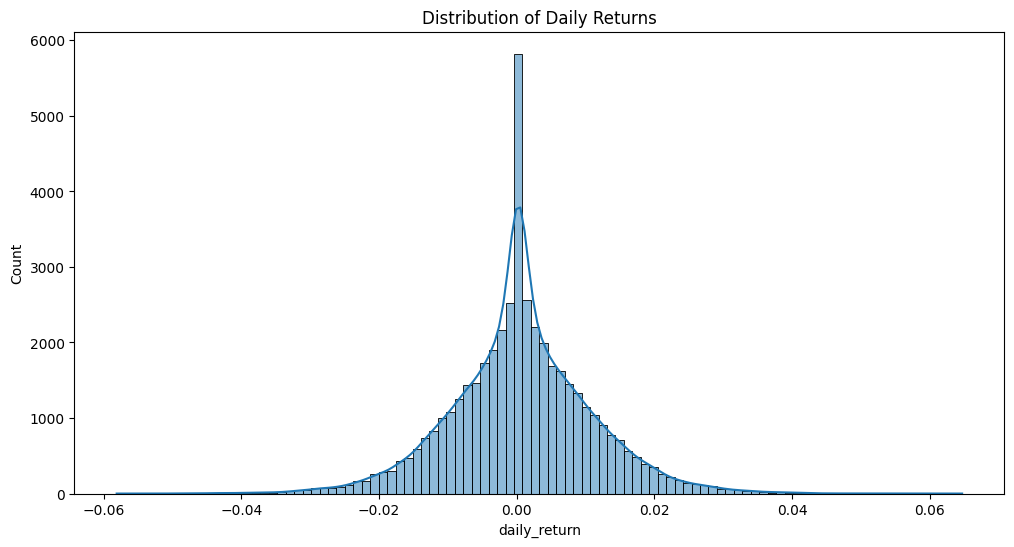

In [2]:
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

plt.figure(figsize=(12,6))

sns.histplot(
    nav["daily_return"],
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.show()

In [3]:
def calculate_cagr(df, years):

    start_date = (
        df["date"].max()
        - pd.DateOffset(years=years)
    )

    recent = df[df["date"] >= start_date]

    if len(recent) < 2:
        return np.nan

    nav_start = recent.iloc[0]["nav"]
    nav_end = recent.iloc[-1]["nav"]

    return (
        (nav_end / nav_start)
        ** (1 / years)
        - 1
    )

In [7]:
cagr_table = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ]

    cagr_table.append({
        "amfi_code": code,
        "cagr_1yr": calculate_cagr(fund, 1),
        "cagr_3yr": calculate_cagr(fund, 3),
        "cagr_5yr": calculate_cagr(fund, 5)
    })

cagr_table = pd.DataFrame(cagr_table)

cagr_table = cagr_table.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

print(cagr_table)

    amfi_code  cagr_1yr  cagr_3yr  cagr_5yr  \
0      100016 -0.022243  0.012926  0.023168   
1      100025  0.037050  0.039164  0.039127   
2      100033  0.532324  0.324425  0.260741   
3      101206  0.479241  0.289677  0.204427   
4      101207 -0.239860 -0.041524  0.069533   
5      101208  0.072366  0.063158  0.057057   
6      102885  0.202077  0.196673  0.158788   
7      102886 -0.167975 -0.007674  0.010303   
8      102887  0.135831  0.255562  0.146781   
9      118632  0.339810  0.226524  0.208811   
10     118633  0.255400  0.210900  0.141884   
11     118634  0.158112  0.080079  0.142741   
12     118635  0.224932  0.200082  0.139144   
13     118636  0.104549  0.040622  0.046639   
14     119092  0.016091  0.005259  0.055826   
15     119093  0.197667  0.208168  0.069174   
16     119094  0.222611  0.351118  0.244453   
17     119095 -0.427976 -0.117058  0.013376   
18     119120  0.055220  0.058404  0.051644   
19     119551  0.604373  0.304565  0.223849   
20     119552

In [8]:
rf = 0.065

sharpe = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ]

    returns = (
        fund["daily_return"]
        .dropna()
    )

    if len(returns) == 0:
        continue

    annual_return = (
        returns.mean() * 252
    )

    annual_std = (
        returns.std()
    )

    # Avoid division by zero
    if annual_std == 0:
        sharpe_ratio = np.nan
    else:
        sharpe_ratio = (
            (annual_return - rf)
            / annual_std
        ) * np.sqrt(252)

    sharpe.append({
        "amfi_code": code,
        "sharpe_ratio": sharpe_ratio
    })

sharpe = pd.DataFrame(sharpe)

print(sharpe)

    amfi_code  sharpe_ratio
0      100016    -50.782301
1      100025   -142.907888
2      100033    275.612083
3      101206    258.857759
4      101207     40.990514
5      101208   -205.522977
6      102885    205.909033
7      102886    -51.869565
8      102887    156.118433
9      118632    272.578113
10     118633    162.592274
11     118634    113.005370
12     118635    167.543964
13     118636    -89.870636
14     119092      7.757782
15     119093     32.662853
16     119094    251.554209
17     119095    -19.145340
18     119120    -57.096997
19     119551    304.483175
20     119552    240.226433
21     119598    238.217681
22     119599    -14.411030
23     120503    201.089160
24     120504    258.684120
25     120505    297.385502
26     120506    163.517451
27     120507    124.922295
28     120841    124.556680
29     120842     19.151962
30     120843    329.299480
31     120844    -22.364319
32     125497    195.499143
33     125498     75.754204
34     148567    364

In [9]:
rf = 0.065

sortino = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ]

    returns = (
        fund["daily_return"]
        .dropna()
    )

    if len(returns) == 0:
        continue

    downside = returns[
        returns < 0
    ]

    annual_return = (
        returns.mean() * 252
    )

    downside_std = downside.std()

    # Avoid division by zero or NaN
    if len(downside) == 0 or pd.isna(downside_std) or downside_std == 0:
        sortino_ratio = np.nan
    else:
        sortino_ratio = (
            (annual_return - rf)
            / downside_std
        ) * np.sqrt(252)

    sortino.append({
        "amfi_code": code,
        "sortino_ratio": sortino_ratio
    })

sortino = pd.DataFrame(sortino)

sortino = sortino.sort_values(
    "sortino_ratio",
    ascending=False
)

print(sortino.head())

    amfi_code  sortino_ratio
34     148567     601.182382
30     120843     595.808648
36     148569     541.022309
19     119551     539.347317
25     120505     511.396941
